## **Notebook Structure**
1. Problem Understanding & objective
2. Exploratory Data Analysis (EDA)
3. Defining Instructor Effectiveness
4. Aggregating Batch Data to Instructor Level
5. Build a Machine Learning Model
6. Model Evaluation
7. Interpreting results
9. Mandatory Analysis Questions
10. Conclusion



#Problem understanding
###In this problem, instructors teach multiple batches and their performance can vary across them. We need to analyze different metrics like learner outcomes, engagement, and feedback to evaluate overall effectiveness. Since effectiveness is not directly given, we have to define it ourselves.








Goal is to predict instructor effectiveness using ML model

*   Each row represents a batch, not an instructor
*   One instructor can teach multiple batches and courses
*   Need to aggregate batch data to instructor level
*   No predefined target → we must create effectiveness score and tiers
*   Goal is to predict instructor effectiveness using ML model








##**OBJECTIVE**
####The objective of this project is to analyze instructor performance using learner outcomes, engagement, and feedback data from different course batches. Since instructor effectiveness is not directly given, we will create an effectiveness score and divide instructors into different tiers. We will also build a machine learning model to predict these tiers and understand which factors affect instructor performance the most.


#Load the data

In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
#loading dataset
df = pd.read_csv("instructor_effectiveness_dataset.csv")
df.head()


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [170]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [171]:
df.shape

(2000, 12)

#Step 1 — Exploratory Data Analysis (EDA)

###Check for missing values

In [172]:
df.isnull().sum()

,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


###Distribution of metrics

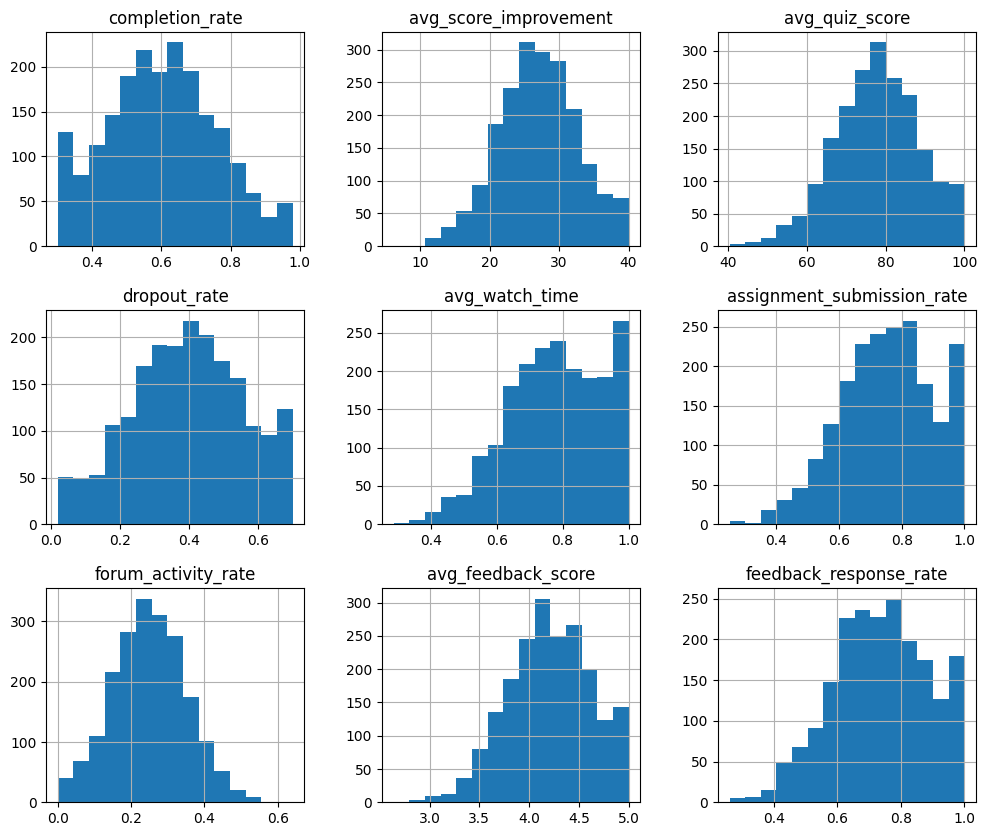

In [173]:
df.hist(figsize=(12,10), bins=15)
plt.show()

##correlation

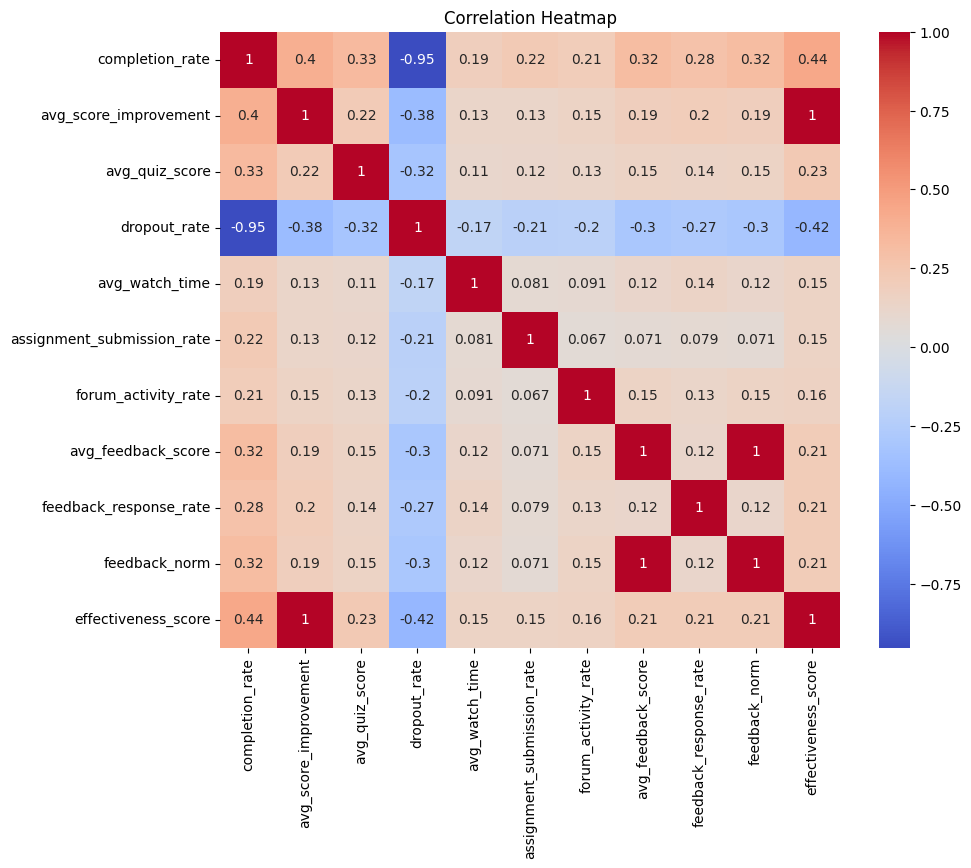

In [195]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

###Check Distribution of completion rate vs dropout_rate

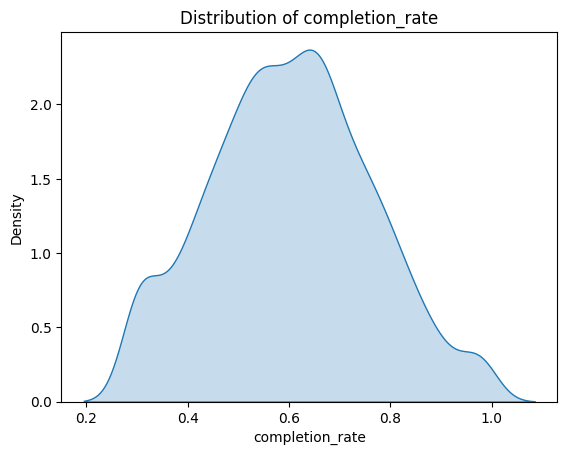

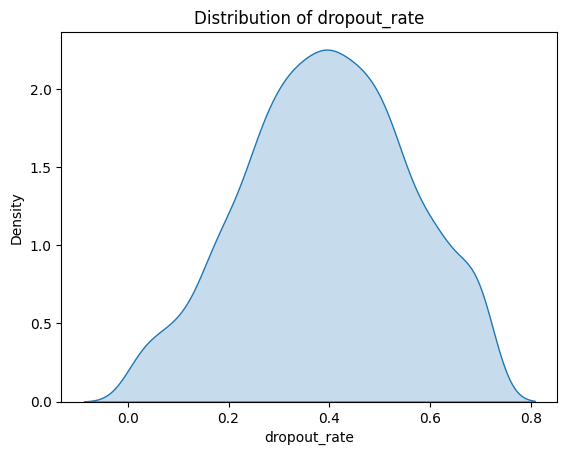

In [174]:

cols = [
    'completion_rate','dropout_rate'
]

for col in cols:
    plt.figure()
    sns.kdeplot(df[col], fill=True)
    plt.title(f"Distribution of {col}")
    plt.show()

#step-2 Define Instructor Effectiveness

In [175]:
# Normalize feedback score
df['feedback_norm'] = df['avg_feedback_score'] / 5

# Weighted score
df['effectiveness_score'] = (
    0.35 * df['completion_rate'] +
    0.25 * df['avg_score_improvement'] +
    0.15 * df['avg_watch_time'] +
    0.15 * df['assignment_submission_rate'] +
    0.10 * df['feedback_norm']
)

###converting score to tiers

In [176]:
df['effectiveness_tier'] = pd.qcut(df['effectiveness_score'], 3, labels=['Low','Medium','High'])
df[['batch_id','instructor_id','effectiveness_score','effectiveness_tier']].head()

,batch_id,instructor_id,effectiveness_score,effectiveness_tier
0,B_1861,I_044,3.971636,Low
1,B_0354,I_119,6.271830,Low
2,B_1334,I_050,4.465007,Low
3,B_0906,I_024,6.581811,Low
4,B_1290,I_001,8.310970,High


In [177]:
instructor_df = df.groupby('instructor_id').agg({
    'effectiveness_score': 'mean',
    'batch_id': 'count'
}).reset_index()

###Getting top 10 instructor by their effectiveness

In [178]:
top10 = instructor_df.sort_values(
    by='effectiveness_score', ascending=False
).head(10)

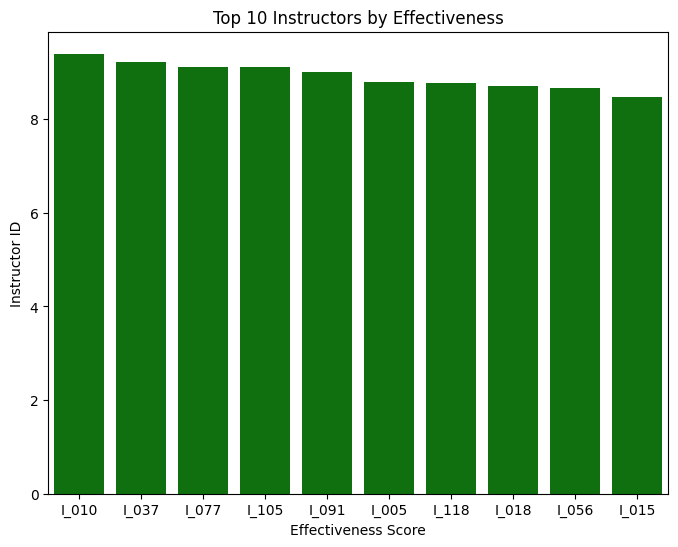

In [197]:
plt.figure(figsize=(8,6))

sns.barplot(
    y='effectiveness_score',
    x='instructor_id',
    data=top10,color = 'green'
)

plt.title("Top 10 Instructors by Effectiveness")
plt.xlabel("Effectiveness Score")
plt.ylabel("Instructor ID")

plt.show()

#Step-3 aggregate batch data to instructor level

In [180]:
# Aggregation functions
instructor_df = df.groupby('instructor_id').agg({
    'completion_rate':['mean','median','std'],
    'dropout_rate':['mean','median','std'],
    'avg_score_improvement':['mean','median'],
    'avg_quiz_score':['mean','median'],
    'avg_watch_time':['mean','median'],
    'assignment_submission_rate':['mean','median'],
    'forum_activity_rate':['mean','median'],
    'feedback_norm':['mean','median'],
    'effectiveness_score':'mean',
    'batch_id':'count'
})

instructor_df.columns = ['_'.join(col).strip() for col in instructor_df.columns.values]
instructor_df = instructor_df.reset_index()

# Recreate tier
instructor_df['tier'] = pd.qcut(instructor_df['effectiveness_score_mean'], 3, labels=['Low','Medium','High'])

###**Which aggregation functions you used and Why they make sense ?**
####I used mean, median, and standard deviation for aggregation. Mean helps to understand the average performance of an instructor across batches, while median reduces the impact of extreme values. Standard deviation shows how consistent the instructor is across different batches.

####I also used count (number of batches) to understand how much data is available for each instructor, which helps in making the analysis more reliable.

###**why we used mean for effectiveness?** 👆
####Mean shows the average performance of an instructor across all their batches. It helps us understand how the instructor usually performs overall, instead of focusing on just one batch.

In [181]:
instructor_df.head()


,instructor_id,completion_rate_mean,completion_rate_median,completion_rate_std,dropout_rate_mean,dropout_rate_median,dropout_rate_std,avg_score_improvement_mean,avg_score_improvement_median,avg_quiz_score_mean,...,avg_watch_time_median,assignment_submission_rate_mean,assignment_submission_rate_median,forum_activity_rate_mean,forum_activity_rate_median,feedback_norm_mean,feedback_norm_median,effectiveness_score_mean,batch_id_count,tier
0,I_001,0.543887,0.545357,0.084611,0.470593,0.471357,0.087671,26.641462,26.112106,78.900194,...,0.733658,0.726893,0.738582,0.240551,0.251056,0.843549,0.849990,7.159092,25,Medium
1,I_002,0.730874,0.723018,0.103691,0.247194,0.254720,0.098811,30.166242,30.453036,81.737198,...,0.853840,0.774394,0.762905,0.289610,0.287592,0.868600,0.849306,8.125995,20,High
2,I_003,0.768447,0.754272,0.120452,0.234828,0.234093,0.115966,29.977813,29.786063,81.590928,...,0.825693,0.779606,0.757713,0.296224,0.304923,0.890007,0.886000,8.092117,18,High
3,I_004,0.458328,0.431807,0.067596,0.547261,0.552827,0.083598,22.912021,21.240292,77.680317,...,0.785699,0.758317,0.748872,0.226259,0.229930,0.815282,0.811362,6.202665,17,Low
4,I_005,0.859747,0.871484,0.090287,0.145733,0.103964,0.097634,32.588652,32.768176,85.828159,...,0.871003,0.876942,0.864285,0.333519,0.328823,0.840503,0.844737,8.790720,19,High


In [182]:
instructor_df.rename(columns={
    'batch_id_count': 'num_batches',
    'effectiveness_score_mean' : 'effectiveness_score'
}, inplace=True)

In [183]:
instructor_df.columns

Index(['instructor_id', 'completion_rate_mean', 'completion_rate_median',
       'completion_rate_std', 'dropout_rate_mean', 'dropout_rate_median',
       'dropout_rate_std', 'avg_score_improvement_mean',
       'avg_score_improvement_median', 'avg_quiz_score_mean',
       'avg_quiz_score_median', 'avg_watch_time_mean', 'avg_watch_time_median',
       'assignment_submission_rate_mean', 'assignment_submission_rate_median',
       'forum_activity_rate_mean', 'forum_activity_rate_median',
       'feedback_norm_mean', 'feedback_norm_median', 'effectiveness_score',
       'num_batches', 'tier'],
      dtype='object')

###Effectiveness vs number of batches

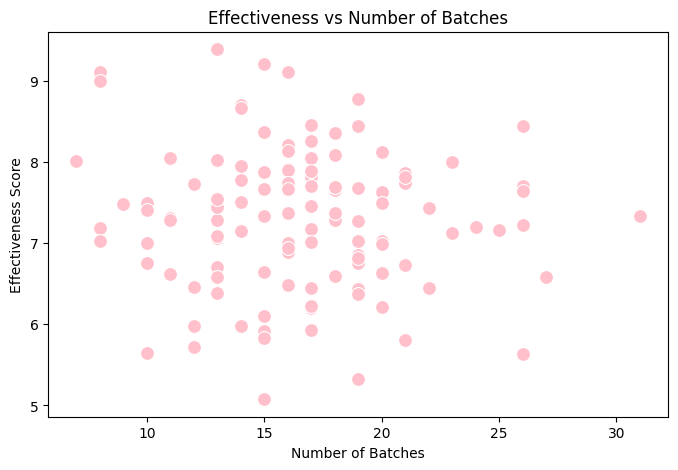

In [184]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='num_batches',
    y='effectiveness_score',
    data=instructor_df,
    color='pink',
    s=100  # bubble size
)

plt.title("Effectiveness vs Number of Batches")
plt.xlabel("Number of Batches")
plt.ylabel("Effectiveness Score")

plt.show()

#Step -4 Building  machine learning model

###feature engineering

In [185]:
instructor_df['dropout_completion_ratio'] = instructor_df['dropout_rate_mean'] / (instructor_df['completion_rate_mean']+1e-5)
instructor_df['engagement_score'] = (
    instructor_df['avg_watch_time_mean'] +
    instructor_df['assignment_submission_rate_mean'] +
    instructor_df['forum_activity_rate_mean']
)/3

###Prepare ML data

In [186]:
X = instructor_df.drop(['instructor_id','tier','effectiveness_score'], axis=1)
y = instructor_df['tier']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [187]:
X_train.shape

(96, 21)

In [188]:
X_test.shape

(24, 21)

###Train ML data

In [189]:


model = RandomForestClassifier(random_state=42, n_estimators=200)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

#Step-5 Evaluate the model

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         9
         Low       1.00      0.88      0.93         8
      Medium       0.88      1.00      0.93         7

    accuracy                           0.96        24
   macro avg       0.96      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



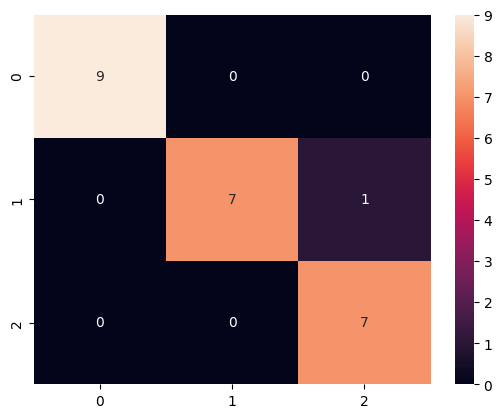

In [190]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

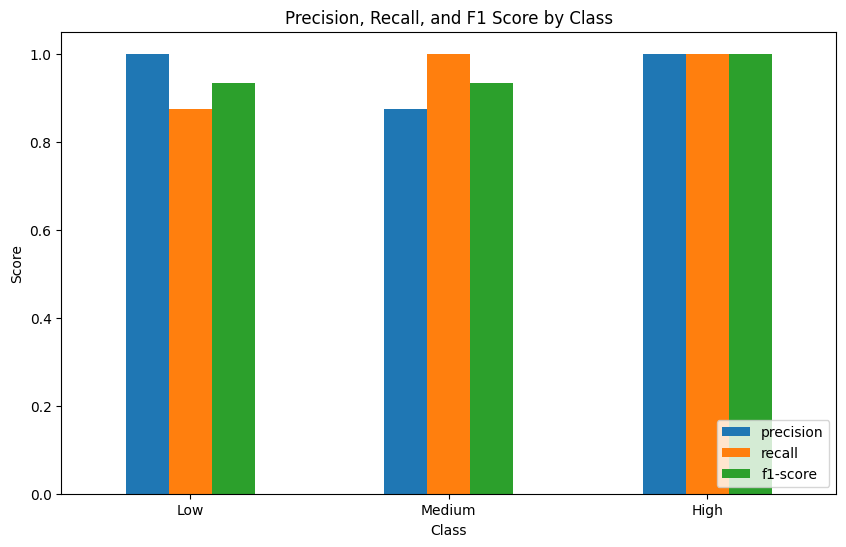

In [191]:
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

classes_only = report_df.loc[['Low','Medium','High']]

metrics_only = classes_only[['precision','recall','f1-score']]
metrics_only.plot(kind='bar', figsize=(10,6))

plt.title("Precision, Recall, and F1 Score by Class")
plt.ylabel("Score")
plt.xlabel("Class")

plt.xticks(rotation=0)
plt.legend(loc='lower right')

plt.show()

###**Trade off precision vs recall**
####There is a trade-off between precision and recall, where improving one can reduce the other. If the model focuses on high recall, it may identify more low-performing instructors but also make more incorrect predictions. If it focuses on high precision, it will be more accurate but may miss some low-performing instructors.

#Step-6 Interpreting the results

####The results indicate that instructor effectiveness is strongly influenced by learner outcomes and engagement. Instructors who are able to keep students engaged, ensure course completion, and improve performance tend to be more effective. Key features like engagement score and dropout-to-completion ratio further support this observation.


*   Completion rate and score improvement are strong indicators of teaching effectiveness
*   Higher engagement (watch time, assignments, forums) leads to better outcomes
*   Higher engagement (watch time, assignments, forums) leads to better outcomes
*   Effective instructors keep learners active and improve their performance
*   These insights can help identify top instructors and improve training strategies





#-------------------------------------------------------------------------------

# **Final analysis Question**

###**Q1 Which features most influenced instructor effectiveness, and why?**
####Instructor effectiveness was mainly influenced by **completion rate**, **score improvement**, and **overall engagement**. The engagement score, which combines watch time, assignment submission, and forum activity, showed that more active learners led to better outcomes. The dropout-to-completion ratio also helped highlight instructors where students were more likely to leave, indicating lower effectiveness.

###**Q2 Which variables could be misleading or confounded?**
####Some variables like feedback scores can be misleading as they are subjective and may not reflect actual learning. High engagement metrics may also be confounded, as motivated learners can make an instructor appear more effective. Additionally, completion rate can vary due to course difficulty rather than instructor quality

###**Q3 How could this model fail in real-world usage**
####This model can fail if it doesn’t consider things like **course difficulty** or **student background**. Sometimes instructors teaching easier courses may look more effective, which can give wrong results. Also, if things change over time, the model might not stay accurate.

### **Q4 What additional data would you want to improve this analysis?**
####To improve this analysis, I would want data about **course difficulty** and **student background**. Information like **instructor experience** and **teaching style** could also help. Additionally, data on long-term learning outcomes would make the model more accurate.

### **Q5 Should this model be used for instructor performance evaluation? Why or why not?**
####This model can be used for instructor evaluation, but it should not be the only factor. Including other aspects like course difficulty, student background, and instructor experience can improve its effectiveness. Combining this model with additional data can make the evaluation more accurate and fair.